#Import Data/Merge

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")

In [ ]:
reviews_df = pd.read_csv('/content/drive/MyDrive/BUSAN307 Colab/Individual Assignment/Aggregate_sentiment_NY_reviews.csv')
listings_df = pd.read_csv('/content/drive/MyDrive/BUSAN307 Colab/Individual Assignment/listings New York.csv')

reviews_df.head()

,listing_id,Average Sentiment
0,2060,0.312708
1,2595,0.337270
2,3831,0.351772
3,5099,0.310538
4,5121,0.409002


In [ ]:
reviews_df.head()

,listing_id,Average Sentiment
0,2060,0.312708
1,2595,0.337270
2,3831,0.351772
3,5099,0.310538
4,5121,0.409002


In [ ]:
listings_df.head()

,listing_id,Space Word Count,Description Word Count,host_response_rate,host_acceptance_rate,host_is_superhost,is_location_exact,room_type,accommodates,bathrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,reviews_per_month
0,2060,69,69,0%,50%,f,t,Private room,2,NaN,...,NaN,NaN,NaN,NaN,f,f,flexible,f,f,0.01
1,2595,153,157,84%,37%,f,f,Entire home/apt,2,1.0,...,10.0,10.0,10.0,9.0,f,f,strict_14_with_grace_period,t,t,0.37
2,3831,174,168,97%,95%,f,t,Entire home/apt,3,1.0,...,9.0,9.0,9.0,8.0,f,f,flexible,f,f,4.64
3,5099,183,183,NaN,67%,f,f,Entire home/apt,2,1.0,...,10.0,10.0,10.0,9.0,f,f,moderate,t,t,0.58
4,5121,182,182,NaN,67%,f,f,Private room,2,NaN,...,10.0,10.0,9.0,9.0,f,f,strict_14_with_grace_period,f,f,0.37


In [ ]:
#Merged Listings and Review
merged_df = listings_df.merge(reviews_df, on="listing_id", how="left")

In [ ]:
merged_df.to_csv("airbnb_merged.csv", index=False)
from google.colab import files
files.download("airbnb_merged.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(reviews_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   listing_id         961 non-null    int64  
 1   Average Sentiment  961 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 15.1 KB
None


In [ ]:
print("=== REVIEWS DATASET ===")
print("Shape:", reviews_df.shape)
print("\nColumns:\n", reviews_df.columns)
print("\nInfo:")
print(reviews_df.info())
print("\nMissing values:\n", reviews_df.isnull().sum())
print("\nSummary statistics:\n", reviews_df.describe())
print("\nFirst 5 rows:\n", reviews_df.head())

=== REVIEWS DATASET ===
Shape: (961, 2)

Columns:
 Index(['listing_id', 'Average Sentiment'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   listing_id         961 non-null    int64  
 1   Average Sentiment  961 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 15.1 KB
None

Missing values:
 listing_id           0
Average Sentiment    0
dtype: int64

Summary statistics:
           listing_id  Average Sentiment
count     961.000000         961.000000
mean   201416.057232           0.373311
std    137202.017029           0.068155
min      2060.000000           0.000000
25%     65562.000000           0.341667
50%    204833.000000           0.379467
75%    292266.000000           0.409651
max    478053.000000           0.700000

First 5 rows:
    listing_id  Average Sentiment
0        2060          

In [ ]:
print("\n\n=== LISTINGS DATASET ===")
print("Shape:", listings_df.shape)
print("\nColumns:\n", listings_df.columns)
print("\nInfo:")
print(listings_df.info())
print("\nMissing values:\n", listings_df.isnull().sum())
print("\nSummary statistics:\n", listings_df.describe())
print("\nFirst 5 rows:\n", listings_df.head())



=== LISTINGS DATASET ===
Shape: (1000, 29)

Columns:
 Index(['listing_id', 'Space Word Count', 'Description Word Count',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'is_location_exact', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'bed_type', 'price', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'is_business_travel_ready',
       'cancellation_policy', 'require_guest_profile_picture',
       'require_guest_phone_verification', 'reviews_per_month'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  ---

In [ ]:
print("\n\n=== MERGED DATASET ===")
print("Shape:", merged_df.shape)
print("\nColumns:\n", merged_df.columns)
print("\nInfo:")
print(merged_df.info())
print("\nMissing values:\n", merged_df.isnull().sum())
print("\nSummary statistics:\n", merged_df.describe())
print("\nFirst 5 rows:\n", merged_df.head())



=== MERGED DATASET ===
Shape: (1000, 30)

Columns:
 Index(['listing_id', 'Space Word Count', 'Description Word Count',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'is_location_exact', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'bed_type', 'price', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'is_business_travel_ready',
       'cancellation_policy', 'require_guest_profile_picture',
       'require_guest_phone_verification', 'reviews_per_month',
       'Average Sentiment'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                     

#Model

In [ ]:
merged_df.head()

,listing_id,Space Word Count,Description Word Count,host_response_rate,host_acceptance_rate,host_is_superhost,is_location_exact,room_type,accommodates,bathrooms,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,reviews_per_month,Average Sentiment
0,2060,69,69,0%,50%,f,t,Private room,2,NaN,...,NaN,NaN,NaN,f,f,flexible,f,f,0.01,0.312708
1,2595,153,157,84%,37%,f,f,Entire home/apt,2,1.0,...,10.0,10.0,9.0,f,f,strict_14_with_grace_period,t,t,0.37,0.337270
2,3831,174,168,97%,95%,f,t,Entire home/apt,3,1.0,...,9.0,9.0,8.0,f,f,flexible,f,f,4.64,0.351772
3,5099,183,183,NaN,67%,f,f,Entire home/apt,2,1.0,...,10.0,10.0,9.0,f,f,moderate,t,t,0.58,0.310538
4,5121,182,182,NaN,67%,f,f,Private room,2,NaN,...,10.0,9.0,9.0,f,f,strict_14_with_grace_period,f,f,0.37,0.409002


const                     float64
price                     float64
accommodates                int64
bathrooms                 float64
bedrooms                  float64
beds                      float64
review_scores_rating      float64
Average Sentiment         float64
room_type_Hotel room        int64
room_type_Private room      int64
room_type_Shared room       int64
bed_type_Couch              int64
bed_type_Futon              int64
bed_type_Pull-out Sofa      int64
bed_type_Real Bed           int64
instant_bookable_t          int64
dtype: object
                            OLS Regression Results                            
Dep. Variable:      reviews_per_month   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     4.000
Date:                Sat, 18 Oct 2025   Prob (F-statistic):           5.18e-07
Time:                        09:57:36   Log-Lik

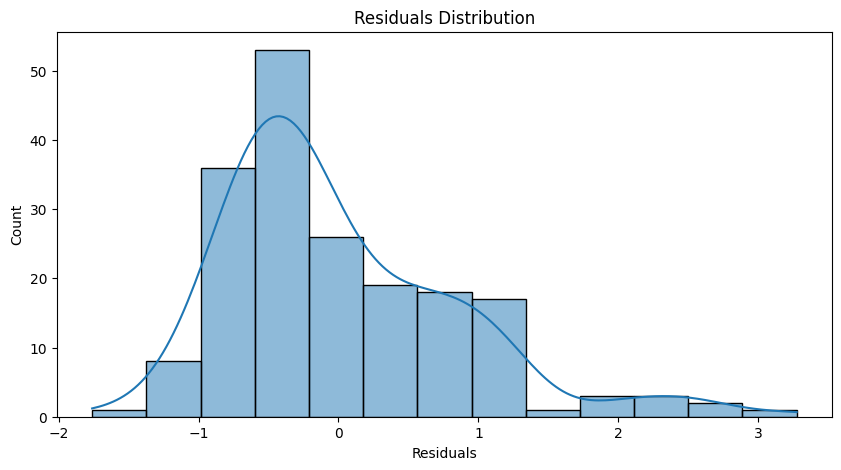

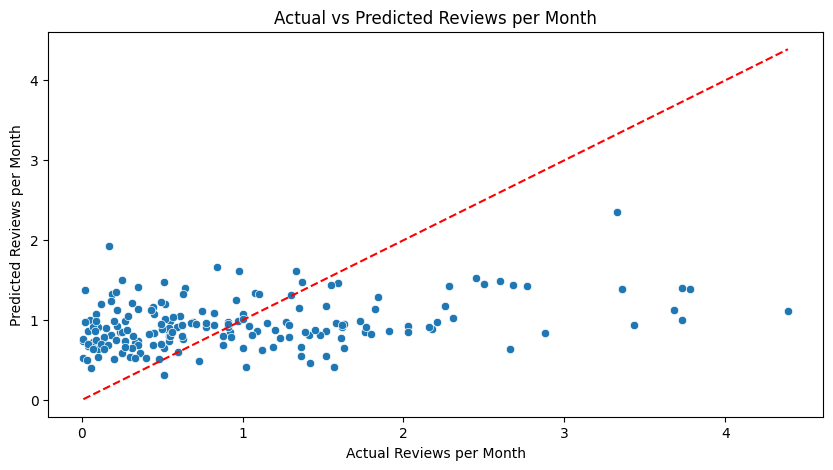

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# Use your merged_df
df = merged_df.copy()

# Convert 'price' to numeric, coercing errors
df['price'] = df['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Select features (based on your dashboard and dataset)
features = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
            'review_scores_rating', 'Average Sentiment',
            'room_type', 'bed_type', 'instant_bookable', 'is_business_travel_ready']

# Drop rows with missing values in selected features or target
df_model = df[features + ['reviews_per_month']].dropna()

# Encode categorical features using get_dummies
categorical_cols = ['room_type', 'bed_type', 'instant_bookable', 'is_business_travel_ready']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Convert boolean columns to integers
for col in df_model.columns:
    if df_model[col].dtype == bool:
        df_model[col] = df_model[col].astype(int)

# Define X and y
X = df_model.drop(columns=['reviews_per_month'])
y = df_model['reviews_per_month']

# Add constant for statsmodels
X = sm.add_constant(X)

# Print data types to identify object columns
print(X.dtypes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())

# Predict
y_pred = model.predict(X_test)

# Residual plot
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred
plt.figure(figsize=(10,5))
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.show()

# Actual vs Predicted
plt.figure(figsize=(10,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Reviews per Month")
plt.ylabel("Predicted Reviews per Month")
plt.title("Actual vs Predicted Reviews per Month")
plt.show()